In [17]:
import glob
import matplotlib.pyplot as plt

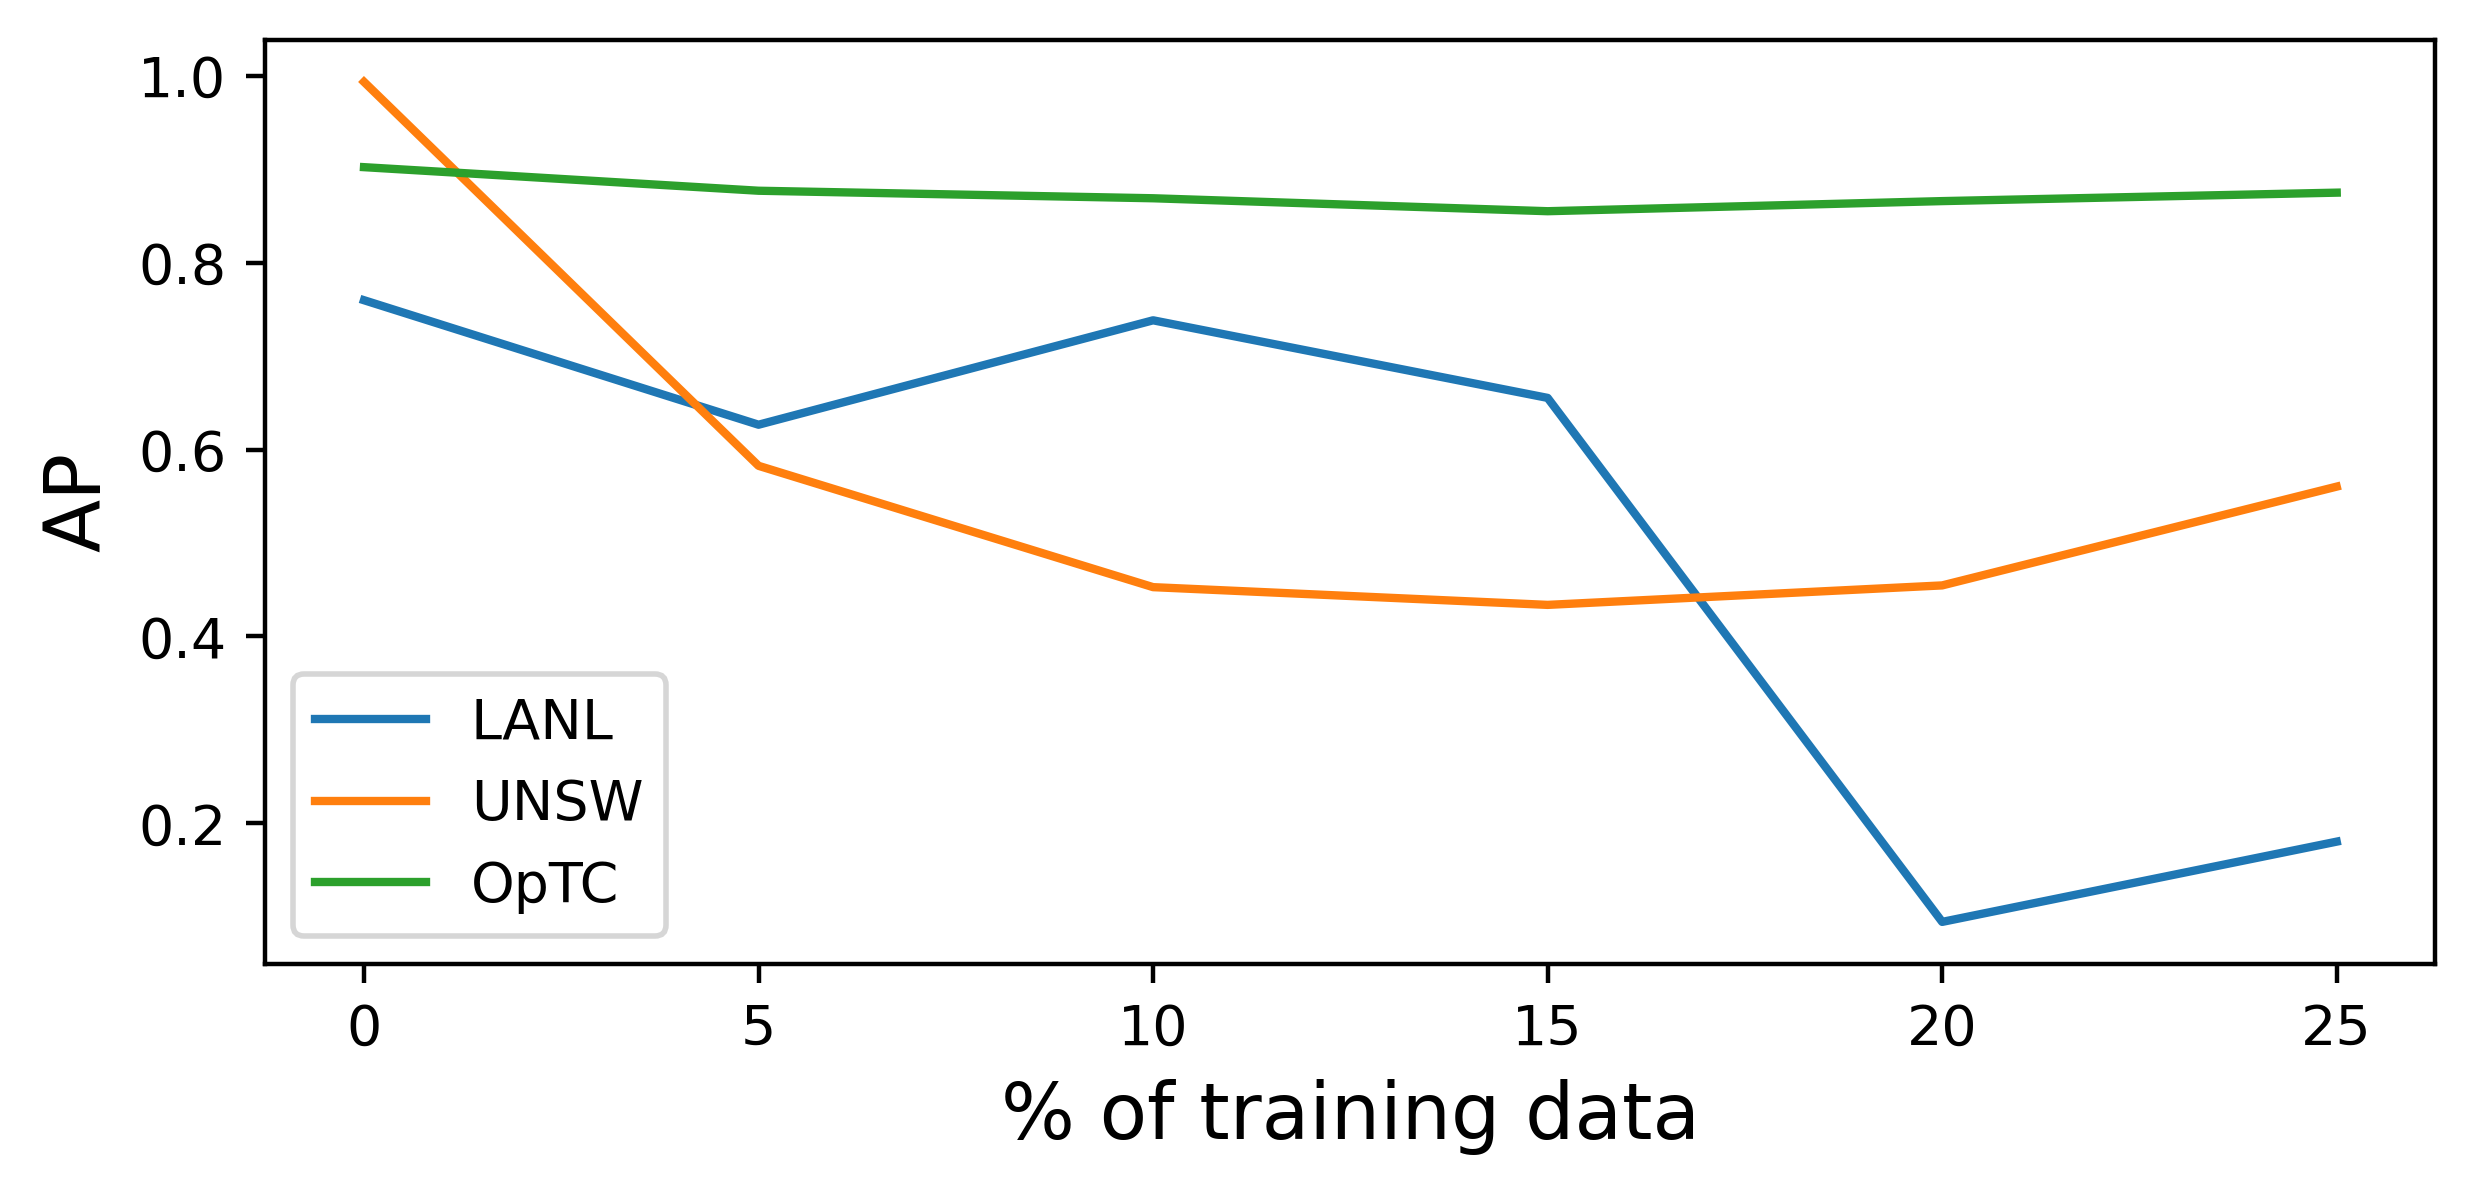

In [18]:
def get_score(f):
    with open(f, 'r') as f_:
        logs = f_.read().split('\n')[2:6]

    best_val = 0
    ap,auc = 0,0
    for l in logs:
        if not l:
            continue

        row = [float(s) for s in l.split(',')]
        v = row[5]
        if v > best_val:
            best_val = v
            auc = row[2]
            ap = row[3]

    return auc,ap

normal_score = {
    'optc': [0, 0.9877, 0.9025],
    'unsw': [0, 0.9951, 0.9938],
    'lanl': [0, 0.9993523204860715,0.7600463223970952]
}

def load_scores(ds):
    files = glob.glob(f'../results/poison-ablation/{ds}/*.txt')

    stats = [normal_score[ds]]
    for file in files:
        try:
            pct = file.split('_')[5].replace('poisoned', '')
            pct = float(pct)
        except:
            continue

        stats.append([pct, *get_score(file)])

    stats.sort(key=lambda x : x[0])
    return stats

def plot_scores(scores, label):
    x,auc,ap = zip(*scores)
    plt.plot(x, ap, label=label)

plt.figure(figsize=(7, 3), dpi=400)
plot_scores(load_scores('lanl'), 'LANL')
plot_scores(load_scores('unsw'), 'UNSW')
plot_scores(load_scores('optc'), 'OpTC')
plt.ylabel('AP', size=14)
plt.xlabel('% of training data', size=14)
plt.legend()
plt.show()